# Figure 8: Frequency- and Phase-Dependent Effects of Rhythmic Inhibition on the Perisomatic Region

This notebook analyzes how rhythmic inhibition delivered to perisomatic compartments (soma and dendrites within 100 µm) affects somatic membrane potential and action potential threshold across different frequencies (0.5-80 Hz). Based on Headley et al. (2026), *Spatially targeted inhibitory rhythms differentially affect neuronal integration*, eLife.

## Key Findings:

**Gamma frequencies (>40 Hz) uniquely modulate somatic excitability:**
- Keep mean membrane potential equivalent between rhythm phases
- Bias membrane voltage fluctuations toward depolarizing (trough phase) or hyperpolarizing (peak phase) values
- During trough phase: excess of depolarizing membrane potential fluctuations increases responsiveness to excitatory inputs in a phase-dependent manner
- Effect increases with frequency, peaking at ~50 Hz


**Lower frequency inhibition (<50 Hz):**

- Produces phase-dependent shifts in mean membrane potential2. **Frequency** of rhythm

- Trough of inhibition depolarizes soma; peak hyperpolarizes1. **Phase** (peak or trough) of the inhibitory rhythm  

- Phase-dependent difference vanishes above 50 HzAnalyses stratify voltage and threshold by:



**Action Potential Threshold Modulation:**2. **Poisson excitation** at soma and dendrites (stable, non-rhythmic)

- Gamma rhythms at perisomatic sites modulate AP threshold via shunting of voltage-gated Na+ channels1. **Rhythmic inhibition** at perisomatic compartments (11 frequencies: 0.5, 2, 5, 10, 16, 20, 30, 40, 50, 60, 80 Hz)

- Threshold shifts lower during trough phase when inhibition is weakestThe simulations include:

- No change in mean membrane voltage during gamma

- Contrast with beta rhythms on dendrites, which modulate dendritic spikes and change mean voltage## Simulation Details:


In [1]:
import sys
sys.path.append('..') # have to do this for relative imports in jupyter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from src.load_spike_h5 import load_spike_h5
from src.load_v_h5 import load_v_h5
from src.load_axcurrent_csv import load_axcurrent_csv
from src.count_dendevt_files import count_dendevt_files
from src.bin_serser import bin_serser
from src.ser_pt import ser_pt

from scipy.signal import hilbert

## 1.0 Analysis Parameters


These analyses measure how perisomatic rhythmic inhibition affects:

1. **Mean somatic membrane potential** during peak vs. trough phasesFrequency specificity reveals that gamma rhythms (>40 Hz) are uniquely suited to modulate somatic excitability through shunting inhibition while maintaining constant mean voltage, whereas lower frequencies primarily shift the mean membrane potential up or down with phase.

2. **Membrane voltage fluctuations** (1 ms voltage changes) biased by rhythm phase

3. **Action potential voltage threshold** modulated by gamma phase via shunting4. **Phase-dependent responsiveness** to excitatory synaptic inputs

### 1.1 Simulation Constants and Analysis Windows

These parameters define the analysis of perisomatic inhibition effects. Perisomatic inhibition targets the soma and proximal dendrites (<100 µm from soma), primarily mediated by parvalbumin-positive (PV) interneurons that pace gamma rhythms. The voltage and current bin edges capture the range of membrane dynamics during rhythmic modulation.

In [2]:
samps_per_ms = 10 
edges_v = np.arange(-70,-40,0.5)
edges_i = np.linspace(-3,3,160)
edges_dv = np.arange(-10,10,0.25)
sim_win = [0, 3000000] # beginning and start points of simulation in samples
step = 1 #* samps_per_ms
ph_bin_num = 8
edges = np.linspace(-np.pi, np.pi, ph_bin_num)

### 1.2 List Files to Be Processed

For each simulation, the phase of the inhibitory rhythm is calculated from a sinusoidal modulation using the Hilbert transform, allowing analyses to stratify events by rhythm phase.

These simulations implement rhythmic inhibition at **perisomatic compartments** (soma and dendrites within 100 µm) across 11 frequencies from 0.5 to 80 Hz. This frequency sweep reveals how the timescale of rhythmic inhibition interacts with the fast dynamics of action potential initiation at the soma.**Phase Time Series:**



**File Organization:**- Naming convention: {frequency}Hzproximal_inh (e.g., '16Hzproximal_inh')

- Source: W:\DendCompOsc\{frequency}Hzproximal_inh\- Public: D:\DendCompOscPublic\{frequency}Hzproximal_inh\

In [17]:
# locate simulation files
freq_list =  [0.5, 2, 5, 10, 16, 20, 30, 40, 50, 60, 80]
freq_list_str = list(map(str, freq_list))
freq_list_str[0] = 'p5'
root_dir = 'D:\\DendCompOscPublic\\'
# Create sim dictionaries
sim_dicts = {}
for i in range(len(freq_list)):
    sim_name = freq_list_str[i] + 'Hzproximal_inh'
    sim_dir = root_dir + sim_name + '\\' 
    # generate phase time series for inhibitory afferents
    t_ser = np.arange(sim_win[0], sim_win[1], step) / (10000) # seconds
    sin_inh = np.sin(t_ser*freq_list[i]*2*np.pi)
    ph_inh = np.angle(hilbert(sin_inh))
    sim_dicts[freq_list_str[i]] = {'SimName': sim_name, 
                                   'RootDir': sim_dir,
                                   'CaFile': sim_dir + sim_name + '_ca.csv',
                                   'NaFile': sim_dir + sim_name + '_na.csv',
                                   'NMDAFile': sim_dir + sim_name + '_nmda.csv', 
                                   'APFile': sim_dir + 'spikes.h5',
                                   'VmFile': sim_dir + sim_name + '_soma_v.csv',
                                   'InhSin': sin_inh,
                                   'InhPhase': ph_inh,
                                   'Freq': freq_list[i], 
                                   'Location': 'proximal'}


root_pois_dir = 'D:\\DendCompOscPublic\\output_allpoisson\\'
sim_pois_dict = {'SimName': 'output_allpoisson',
               'RootDir': root_pois_dir,
               'CaFile': root_pois_dir + 'output_allpoisson_ca.csv',
               'NaFile': root_pois_dir + 'output_allpoisson_na.csv',
               'NMDAFile': root_pois_dir + 'output_allpoisson_nmda.csv',
               'APFile': root_pois_dir + 'spikes.h5',
               'VMemFile': root_pois_dir + 'output_allpoisson_soma_v.csv'}



## 2.0 Phase-Binned Action Potential Threshold Analysis

- Above 40 Hz: Bias in momentary voltage fluctuations diverges between phases, peaking at 50 Hz

This section calculates how perisomatic rhythmic inhibition modulates action potential generation in a frequency- and phase-dependent manner.- Above 50 Hz: Phase-dependent mean voltage difference vanishes

- Below 50 Hz: Phase modulates mean membrane potential (trough depolarizes, peak hyperpolarizes)

**Key Mechanisms:****Frequency Specificity:**



**Gamma Rhythms (64 Hz in original simulations; 40-80 Hz in frequency sweep):**- Less effective than when delivered to distal dendrites

- Modulate AP threshold via **shunting** of voltage-gated Na+ channels at the axon initial segment- Reflects suppression of dendritic spikes reducing excitatory drive to soma

- Threshold shifts lower during **trough phase** (minimal inhibition)- Decrease mean membrane voltage during peak phase

- **No change in mean membrane voltage** between phases- Raise AP threshold during **peak phase** via "off-path" shunting of excitatory current toward dendrites

- Bias membrane voltage fluctuations: depolarizing during trough, hyperpolarizing during peak**Beta Rhythms (16 Hz) at Perisomatic Sites:**

- This phase-dependent shunting increases sensitivity to rapid excitatory inputs during trough

### 2.1 Calculate Action Potential Threshold Voltage

- This bias increases phase-dependent responsiveness to excitatory inputs despite constant mean voltage

This analysis measures the **voltage threshold for AP initiation** by examining the distribution of somatic membrane potentials 1 ms prior to action potentials, stratified by rhythm phase.- Gamma frequencies bias fluctuations toward depolarizing (trough) or hyperpolarizing (peak) with phase

- Captures how rapidly the membrane potential is changing

**Cumulative Probability Approach:**- Measured as the change in voltage over 1 ms delays

- Compare membrane voltage distributions during peak (maximal inhibition) vs. trough (minimal inhibition) phases

**Membrane Voltage Fluctuations:**

- Gamma rhythms: Threshold shifts lower during trough without changing mean voltage (shunting effect)
- Lower frequencies: Threshold changes accompany shifts in mean membrane potential

In [18]:
# probability of action potentials by membrane voltage
def ap_prob_func(spk, v, edges):
    null_hist = np.histogram(v, edges)
    spk_hist = np.histogram(v[spk-10], edges)
    spk_cum_prob = np.nancumsum(spk_hist[0]/null_hist[0])
    return {'null': null_hist[0], 'spk': spk_hist[0], 'prob': spk_cum_prob}

def thresh_files_func(sim_dict):
    spk_prob = {'v': {}, 'dv': {}}
    sin_ser = sim_dict['InhSin']
    # split action potentials based on phase of rhythm
    spk_t = load_spike_h5(sim_dict['APFile'])
    p_inds = np.where(sin_ser >= 0)
    t_inds = np.where(sin_ser < 0)
    spk_t_p = np.intersect1d(spk_t, p_inds)
    spk_t_t = np.intersect1d(spk_t, t_inds)
    
    # load soma voltage from CSV
    mem_v = pd.read_csv(sim_dict['VmFile'])['voltage_mV'].values
    mem_dv = np.pad(mem_v[10:]-mem_v[:-10], (10, 0), mode='edge')

    # calculate action potential probability by voltage for each phase
    spk_prob['v']['p'] = ap_prob_func(spk_t_p, mem_v, edges_v)
    spk_prob['v']['t'] = ap_prob_func(spk_t_t, mem_v, edges_v)

    # calculate action potential probability by 1 ms change in voltage for each phase
    spk_prob['dv']['p'] = ap_prob_func(spk_t_p, mem_dv, edges_dv)
    spk_prob['dv']['t'] = ap_prob_func(spk_t_t, mem_dv, edges_dv)

    # membrane voltage distribution by phase
    spk_prob['v']['p']['dist'] = np.histogram(mem_v[p_inds], edges_v)[0]
    spk_prob['v']['t']['dist'] = np.histogram(mem_v[t_inds], edges_v)[0]

    # membrane voltage mean by phase
    spk_prob['v']['p']['mean'] = np.nanmean(mem_v[p_inds])
    spk_prob['v']['t']['mean'] = np.nanmean(mem_v[t_inds])

    # change in membrane voltage distribution by phase
    spk_prob['dv']['p']['dist'] = np.histogram(mem_dv[p_inds], edges_dv)[0]
    spk_prob['dv']['t']['dist'] = np.histogram(mem_dv[t_inds], edges_dv)[0]

    # change in membrane voltage mean by phase
    spk_prob['dv']['p']['mean'] = np.nanmean(mem_dv[p_inds])
    spk_prob['dv']['t']['mean'] = np.nanmean(mem_dv[t_inds])

    # process action potential events
    spk_t = load_spike_h5(sim_dict['APFile'])
    spk_ser = ser_pt(spk_t, step, sim_win)
    spk_ser = np.array(spk_ser)/(0.001/samps_per_ms)    # multiplying by 500 converts to firing rates, 2ms bin means 1 spike per bin
    # is a firing rate of 500 Hz.
    spk_prob['ap'] = bin_serser(spk_ser.astype(float), sim_dict['InhPhase'], edges, func=np.nanmean)["values"]
    spk_prob['sin'] = bin_serser(sim_dict['InhSin'], sim_dict['InhPhase'], edges, func=np.nanmean)["values"]

    return spk_prob

def thresh_files_pois_func(sim_dict):
    spk_prob = {'v': {}}

    # split action potentials based on phase of rhythm
    spk_t = load_spike_h5(sim_dict['APFile'])
   
    # load soma voltage from CSV
    mem_v = pd.read_csv(sim_dict['VMemFile'])['voltage_mV'].values

    # calculate action potential probability by voltage
    spk_prob['v']['pois'] = ap_prob_func(spk_t, mem_v, edges_v)
   
    # membrane voltage distribution
    spk_prob['v']['pois']['dist'] = np.histogram(mem_v, edges_v)[0]

    return spk_prob

In [19]:
ph_prob = {}
for k, v in sim_dicts.items():
    print('Processing ' + k)
    ph_prob[k] = thresh_files_func(v)

# process the poisson inhibition simulation
pois_prob = thresh_files_pois_func(sim_pois_dict)

Processing p5


c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\bin_serser.py:60: RuntimeWarning: Mean of empty slice
  bin_temp.append(func(val_ser[bin_inds == curr_ind]))


Processing 2


c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\bin_serser.py:60: RuntimeWarning: Mean of empty slice
  bin_temp.append(func(val_ser[bin_inds == curr_ind]))


Processing 5


...

c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\bin_serser.py:60: RuntimeWarning: Mean of empty slice
  bin_temp.append(func(val_ser[bin_inds == curr_ind]))


Processing 60


c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\bin_serser.py:60: RuntimeWarning: Mean of empty slice
  bin_temp.append(func(val_ser[bin_inds == curr_ind]))


Processing 80


c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\bin_serser.py:60: RuntimeWarning: Mean of empty slice
  bin_temp.append(func(val_ser[bin_inds == curr_ind]))


### 2.2 Phase-Dependent Membrane Voltage and Fluctuation Plots

Gamma frequencies are uniquely suited for modulating perisomatic excitability because they bias membrane voltage fluctuations toward depolarizing or hyperpolarizing values in a phase-dependent manner while keeping mean voltage constant. This allows gamma to modulate the neuron's sensitivity to rapid excitatory inputs without changing its overall excitability level. Since excitatory drive was independent of phase in these simulations, the excess of depolarizing fluctuations during the trough suggests increased responsiveness to synaptic inputs during this phase.

These plots reveal the frequency-specific effects of perisomatic rhythmic inhibition:**Interpretation:**



**Panel 1: Phase-dependent Membrane Voltage**- Peak phase: Negative bias (excess hyperpolarizing fluctuations)

- Shows mean somatic membrane potential during peak (inhibition high) vs. trough (inhibition low) phases- Trough phase: Positive bias (excess depolarizing fluctuations)

- Lower frequencies (<50 Hz): Clear separation between peak and trough mean voltages- Gamma frequencies (40-80 Hz): Divergence increases, peaking around 50-60 Hz

- Higher frequencies (>50 Hz): Phase-dependent difference in mean voltage vanishes- Lower frequencies: Minimal difference in voltage fluctuation bias between phases

- This is consistent with gamma's unique ability to maintain constant mean voltage across phases- Shows mean of 1 ms voltage changes during peak vs. trough phases

**Panel 2: Phase-dependent Delta Voltage (Membrane Fluctuations)**

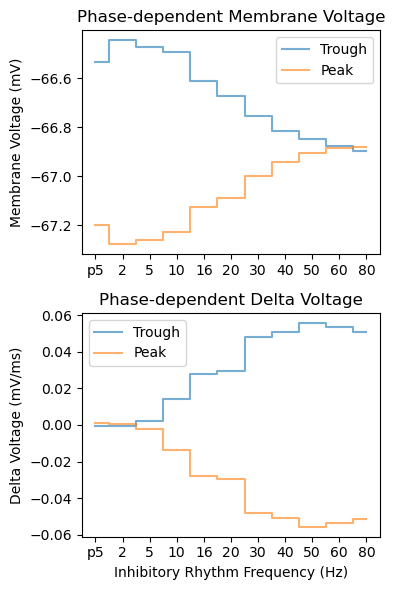

In [20]:
mv_mean_t = np.array([ph_prob[freq]['v']['t']['mean'] for freq in freq_list_str])
mv_mean_p = np.array([ph_prob[freq]['v']['p']['mean'] for freq in freq_list_str])
dv_mean_t = np.array([ph_prob[freq]['dv']['t']['mean'] for freq in freq_list_str])
dv_mean_p = np.array([ph_prob[freq]['dv']['p']['mean'] for freq in freq_list_str])

fig, ax = plt.subplots(2,1, figsize=(4, 6))
ax[0].step(freq_list_str, mv_mean_t, where='mid', label='Trough', alpha=0.6)
ax[0].step(freq_list_str, mv_mean_p, where='mid', label='Peak', alpha=0.6)
ax[1].step(freq_list_str, dv_mean_t, where='mid', label='Trough', alpha=0.6)
ax[1].step(freq_list_str, dv_mean_p, where='mid', label='Peak', alpha=0.6)
ax[0].set_ylabel('Membrane Voltage (mV)')
ax[1].set_ylabel('Delta Voltage (mV/ms)')
ax[1].set_xlabel('Inhibitory Rhythm Frequency (Hz)')
ax[0].set_title('Phase-dependent Membrane Voltage')
ax[1].set_title('Phase-dependent Delta Voltage')
ax[0].legend()
ax[1].legend()
fig.tight_layout()